#Shail Rawat
#2501940011
#Deep Learning Architectures and Techniques (ETMMDL274)
---------------------------------------------------------------------------------------------
# **ASSIGNMENT - 1**
##**Neural Network–Based Credit Risk Prediction Using a Multi-Layer Perceptron (MLP)**
This laboratory assignment focuses on the practical implementation of feedforward neural
networks for binary classification using structured/tabular data. Students will build, train, and
evaluate a Multi-Layer Perceptron (MLP) to predict credit risk, reinforcing core Unit 1
concepts such as neurons, activation functions, loss functions, and optimization.


1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
data = pd.read_csv(url)

print("Dataset Shape:", data.shape)
print(data.head())


Dataset Shape: (1000, 21)
                status  duration                            credit_history  \
0         ... < 100 DM         6   critical account/other credits existing   
1    0 <= ... < 200 DM        48  existing credits paid back duly till now   
2  no checking account        12   critical account/other credits existing   
3         ... < 100 DM        42  existing credits paid back duly till now   
4         ... < 100 DM        24           delay in paying off in the past   

               purpose  amount                     savings  \
0  domestic appliances    1169  unknown/no savings account   
1  domestic appliances    5951                ... < 100 DM   
2           retraining    2096                ... < 100 DM   
3     radio/television    7882                ... < 100 DM   
4            car (new)    4870                ... < 100 DM   

  employment_duration  installment_rate                  personal_status_sex  \
0      ... >= 7 years                 4             

3. Handling Missing Values

In [3]:
data.fillna(method="ffill", inplace=True)


/tmp/ipykernel_349/3318255367.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method="ffill", inplace=True)


4. Encode Categorical Variables

In [4]:
for col in data.select_dtypes(include=["object"]).columns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])


5. Split Features and Target

In [5]:
X = data.drop("credit_risk", axis=1)
y = data["credit_risk"]


6. Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


7. Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


8. Build MLP Model

In [8]:
model = Sequential()

model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

9. Train Model

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.6173 - loss: 0.6548 - val_accuracy: 0.6750 - val_loss: 0.6329
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6740 - loss: 0.5914 - val_accuracy: 0.6812 - val_loss: 0.6078
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7254 - loss: 0.5597 - val_accuracy: 0.6750 - val_loss: 0.5900
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7429 - loss: 0.5324 - val_accuracy: 0.6875 - val_loss: 0.5752
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7422 - loss: 0.5210 - val_accuracy: 0.7063 - val_loss: 0.5667
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7577 - loss: 0.5011 - val_accuracy: 0.7188 - val_loss: 0.5582
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7554 - loss: 0.4979 - val_accuracy: 0.7188 - val_loss: 0.5534
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7459 - loss: 0.4869 - val_accuracy: 0.7437 - v

10. Plot Accuracy

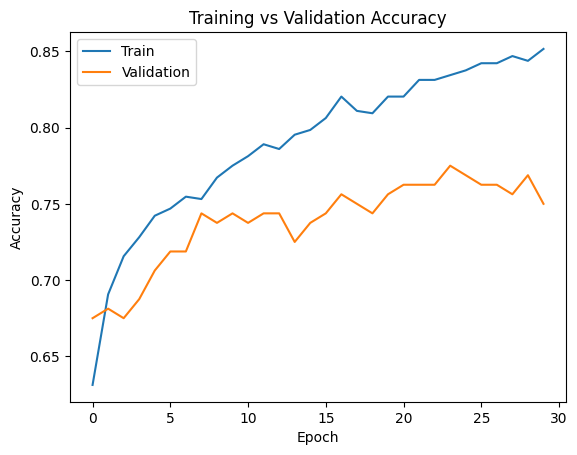

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


11. Plot Loss

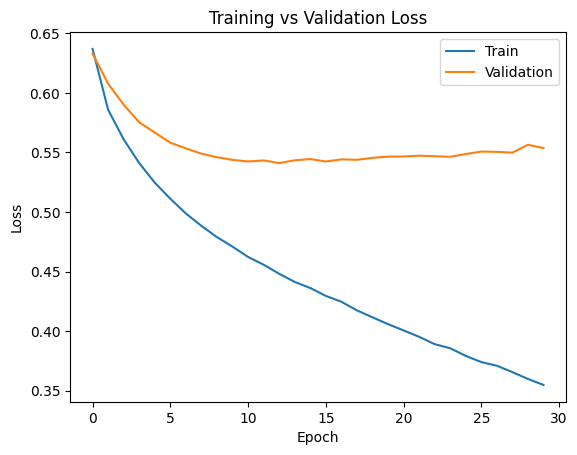

In [11]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


12. Model Evaluation

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


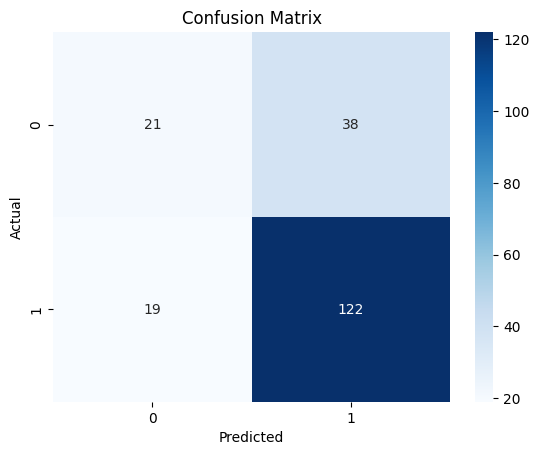


Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.36      0.42        59
           1       0.76      0.87      0.81       141

    accuracy                           0.71       200
   macro avg       0.64      0.61      0.62       200
weighted avg       0.69      0.71      0.70       200



In [12]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))